# DriftGuard — Adaptive Models Under Concept Drift

In this notebook, I extend the streaming classification system with model adaptation.

The previous notebooks established the baseline streaming models and used Page-Hinkley to detect changes in prediction-error behavior. I now connect these components through the **Learn → Detect → Adapt** workflow.

When a change is detected, the models will respond differently:

- Gaussian Naive Bayes will reduce the influence of older statistics.
- Windowed KNN will remove older observations more aggressively.

I will evaluate the adaptive models using the same prequential streaming setup used earlier, so the comparison with the non-adaptive baselines remains fair.

## Objective

My goal is to determine whether adapting the models after detected changes improves their ability to handle a non-stationary data stream.

I will compare:

1. Incremental Gaussian Naive Bayes vs Adaptive Gaussian Naive Bayes
2. Windowed KNN vs Adaptive Windowed KNN

The evaluation will use accuracy, F1-score, recall, and performance across sequential batches.

## Adaptive Gaussian Naive Bayes

I now connect Page-Hinkley with the incremental Gaussian Naive Bayes model.

For each evaluated batch, I first measure the prediction error. Page-Hinkley then checks the batch-level error rate for a change.

When a change is detected, I reduce the influence of the older Gaussian statistics before continuing with new observations.

This gives the model the ability to adapt instead of relying equally on historical data throughout the entire stream.

In [8]:
# Import the adaptive Gaussian Naive Bayes model
from driftaware.models.adaptive_gaussian_nb import AdaptiveGaussianNB

# Import the Page-Hinkley detector
from driftaware.drift.page_hinkley import PageHinkley

# Import evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Create the adaptive Gaussian Naive Bayes model
adaptive_nb = AdaptiveGaussianNB(
    n_features=X.shape[1],
    decay_factor=0.5
)

# Create the Page-Hinkley detector
adaptive_nb_detector = PageHinkley(
    delta=0.01,
    threshold=1.5
)

# Store results for each evaluated batch
adaptive_nb_results = []

# Warm up the model using the first batch
adaptive_nb.update(
    batches[0].drop(columns=["class"]).values,
    batches[0]["class"].values
)

# Process all remaining batches sequentially
for batch_number, batch in enumerate(batches[1:], start=2):

    # Separate features and target
    X_batch = batch.drop(columns=["class"]).values
    y_batch = batch["class"].values

    # Predict before learning from the current batch
    predictions = adaptive_nb.predict(X_batch)

    # Calculate batch metrics
    accuracy = accuracy_score(y_batch, predictions)
    f1 = f1_score(y_batch, predictions)
    recall = recall_score(y_batch, predictions)

    # Calculate the batch error rate
    error_rate = np.mean(predictions != y_batch)

    # Check for a change in the error signal
    drift_detected = adaptive_nb_detector.update(error_rate)

    # Adapt the model when a change is detected
    if drift_detected:
        adaptive_nb.adapt()

    # Learn from the current batch
    adaptive_nb.update(X_batch, y_batch)

    # Store the results
    adaptive_nb_results.append({
        "batch": batch_number,
        "accuracy": accuracy,
        "f1": f1,
        "recall": recall,
        "error_rate": error_rate,
        "drift_detected": drift_detected
    })

# Convert results into a DataFrame
adaptive_nb_results = pd.DataFrame(adaptive_nb_results)

# Calculate the number of adaptation events
adaptation_count = adaptive_nb_results["drift_detected"].sum()

# Calculate mean batch-level metrics
adaptive_nb_accuracy = adaptive_nb_results["accuracy"].mean()
adaptive_nb_f1 = adaptive_nb_results["f1"].mean()
adaptive_nb_recall = adaptive_nb_results["recall"].mean()

# Display the results
print("Batches evaluated:", len(adaptive_nb_results))
print("Adaptation events:", adaptation_count)
print("Mean batch accuracy:", round(adaptive_nb_accuracy, 4))
print("Mean batch F1:", round(adaptive_nb_f1, 4))
print("Mean batch recall:", round(adaptive_nb_recall, 4))

Batches evaluated: 90
Adaptation events: 1
Mean batch accuracy: 0.7162
Mean batch F1: 0.5161
Mean batch recall: 0.4595


In [9]:
# Save the batch-level adaptive NB results
adaptive_nb_results.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\adaptive_nb_streaming_results.csv",
    index=False
)

# Create a compact summary of the adaptive NB experiment
adaptive_nb_summary = pd.DataFrame([{
    "model": "Adaptive Gaussian NB",
    "batches_evaluated": len(adaptive_nb_results),
    "adaptation_events": int(adaptation_count),
    "mean_batch_accuracy": adaptive_nb_accuracy,
    "mean_batch_f1": adaptive_nb_f1,
    "mean_batch_recall": adaptive_nb_recall
}])

# Save the summary
adaptive_nb_summary.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\adaptive_nb_streaming_summary.csv",
    index=False
)

# Display the summary
adaptive_nb_summary

,model,batches_evaluated,adaptation_events,mean_batch_accuracy,mean_batch_f1,mean_batch_recall
0,Adaptive Gaussian NB,90,1,0.716183,0.516148,0.459455


## Adaptive Windowed KNN

I now connect Page-Hinkley with the windowed KNN model.

During normal operation, KNN keeps the most recent 2,000 observations. When Page-Hinkley detects a change in the batch-level error rate, the model removes older observations more aggressively.

This allows KNN to give greater importance to recent observations after a detected change while still retaining some recent historical information.

In [13]:
# Import the adaptive KNN model
from driftaware.models.adaptive_windowed_knn import AdaptiveWindowedKNN

# Create the adaptive KNN model
adaptive_knn = AdaptiveWindowedKNN(
    window_size=2000,
    n_neighbors=5
)

# Create the Page-Hinkley detector
adaptive_knn_detector = PageHinkley(
    delta=0.01,
    threshold=1.0
)

# Store results for each evaluated batch
adaptive_knn_results = []

# Use the first batch for model warm-up
adaptive_knn.update(
    batches[0].drop(columns=["class"]).values,
    batches[0]["class"].values
)

# Process the remaining batches sequentially
for batch_number, batch in enumerate(batches[1:], start=2):

    # Separate features and target
    X_batch = batch.drop(columns=["class"]).values
    y_batch = batch["class"].values

    # Predict before learning from the current batch
    predictions = adaptive_knn.predict(X_batch)

    # Calculate batch metrics
    accuracy = accuracy_score(y_batch, predictions)
    f1 = f1_score(y_batch, predictions)
    recall = recall_score(y_batch, predictions)

    # Calculate the batch error rate
    error_rate = np.mean(predictions != y_batch)

    # Check the error rate for a change
    drift_detected = adaptive_knn_detector.update(error_rate)

    # Adapt the KNN window when a change is detected
    if drift_detected:
        adaptive_knn.adapt()

    # Update the model using the current batch
    adaptive_knn.update(X_batch, y_batch)

    # Store the batch results
    adaptive_knn_results.append({
        "batch": batch_number,
        "accuracy": accuracy,
        "f1": f1,
        "recall": recall,
        "error_rate": error_rate,
        "drift_detected": drift_detected
    })

# Convert the results into a DataFrame
adaptive_knn_results = pd.DataFrame(adaptive_knn_results)

# Count the adaptation events
knn_adaptation_count = adaptive_knn_results["drift_detected"].sum()

# Calculate mean batch-level metrics
adaptive_knn_accuracy = adaptive_knn_results["accuracy"].mean()
adaptive_knn_f1 = adaptive_knn_results["f1"].mean()
adaptive_knn_recall = adaptive_knn_results["recall"].mean()

# Display the results
print("Batches evaluated:", len(adaptive_knn_results))
print("Adaptation events:", knn_adaptation_count)
print("Mean batch accuracy:", round(adaptive_knn_accuracy, 4))
print("Mean batch F1:", round(adaptive_knn_f1, 4))
print("Mean batch recall:", round(adaptive_knn_recall, 4))

Batches evaluated: 90
Adaptation events: 1
Mean batch accuracy: 0.6972
Mean batch F1: 0.614
Mean batch recall: 0.597


In [14]:
# Test several Page-Hinkley thresholds for the KNN error signal
knn_thresholds = [0.5, 0.75, 1.0, 1.25, 1.5]

# Store the detection results
knn_detection_summary = []

for threshold in knn_thresholds:

    # Create a fresh detector
    detector = PageHinkley(
        delta=0.01,
        threshold=threshold
    )

    # Store detected batches
    detected_batches = []

    # Check the KNN error rate of each evaluated batch
    for _, row in adaptive_knn_results.iterrows():

        # Record a batch when a change is detected
        if detector.update(row["error_rate"]):
            detected_batches.append(int(row["batch"]))

    # Save the result
    knn_detection_summary.append({
        "threshold": threshold,
        "number_of_detections": len(detected_batches),
        "detected_batches": detected_batches
    })

# Display the sensitivity results
for result in knn_detection_summary:
    print(
        "Threshold:",
        result["threshold"],
        "| Detections:",
        result["number_of_detections"],
        "| Batches:",
        result["detected_batches"]
    )

Threshold: 0.5 | Detections: 1 | Batches: [51]
Threshold: 0.75 | Detections: 1 | Batches: [63]
Threshold: 1.0 | Detections: 1 | Batches: [69]
Threshold: 1.25 | Detections: 0 | Batches: []
Threshold: 1.5 | Detections: 0 | Batches: []


In [15]:
# Save the batch-level adaptive KNN results
adaptive_knn_results.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\adaptive_knn_streaming_results.csv",
    index=False
)

# Create a compact summary of the adaptive KNN experiment
adaptive_knn_summary = pd.DataFrame([{
    "model": "Adaptive Windowed KNN",
    "batches_evaluated": len(adaptive_knn_results),
    "adaptation_events": int(knn_adaptation_count),
    "mean_batch_accuracy": adaptive_knn_accuracy,
    "mean_batch_f1": adaptive_knn_f1,
    "mean_batch_recall": adaptive_knn_recall
}])

# Save the summary
adaptive_knn_summary.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\adaptive_knn_streaming_summary.csv",
    index=False
)

# Display the summary
adaptive_knn_summary

,model,batches_evaluated,adaptation_events,mean_batch_accuracy,mean_batch_f1,mean_batch_recall
0,Adaptive Windowed KNN,90,1,0.69716,0.613963,0.597001


## Adaptive vs Non-Adaptive Models

I now compare the adaptive models with their non-adaptive counterparts.

The non-adaptive models provide the baseline, while the adaptive models use Page-Hinkley to respond to detected changes.

I will compare accuracy, F1-score, and recall using the same streaming evaluation setup. This allows me to see whether the adaptation strategy provides a meaningful improvement rather than evaluating the adaptive models in isolation.

In [16]:
# Create the final model comparison table
model_comparison = pd.DataFrame([
    {
        "model": "Incremental Gaussian NB",
        "accuracy": 0.7141,
        "f1": 0.5116,
        "recall": 0.4533
    },
    {
        "model": "Adaptive Gaussian NB",
        "accuracy": adaptive_nb_accuracy,
        "f1": adaptive_nb_f1,
        "recall": adaptive_nb_recall
    },
    {
        "model": "Windowed KNN",
        "accuracy": 0.6970,
        "f1": 0.6133,
        "recall": 0.5963
    },
    {
        "model": "Adaptive Windowed KNN",
        "accuracy": adaptive_knn_accuracy,
        "f1": adaptive_knn_f1,
        "recall": adaptive_knn_recall
    }
])

# Display the comparison
model_comparison

,model,accuracy,f1,recall
0,Incremental Gaussian NB,0.714100,0.511600,0.453300
1,Adaptive Gaussian NB,0.716183,0.516148,0.459455
2,Windowed KNN,0.697000,0.613300,0.596300
3,Adaptive Windowed KNN,0.697160,0.613963,0.597001


In [17]:
# Save the final adaptive model comparison
model_comparison.to_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\results\adaptive_model_comparison.csv",
    index=False
)

# Display the saved result
print("Adaptive model comparison saved successfully.")

Adaptive model comparison saved successfully.


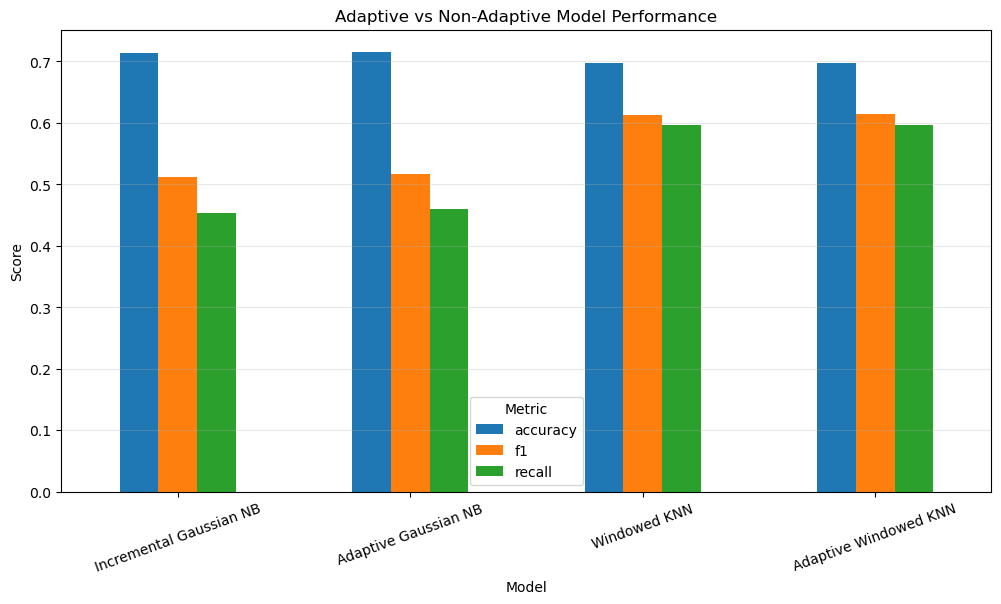

In [19]:
import matplotlib.pyplot as plt
# Create a bar chart comparing model performance
metrics = ["accuracy", "f1", "recall"]

model_comparison.set_index("model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

# Add labels and title
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Adaptive vs Non-Adaptive Model Performance")

# Keep the chart readable
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

# Save the figure
plt.savefig(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\figures\adaptive_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

## Findings

I compared the adaptive models with their non-adaptive counterparts using the same sequential streaming evaluation.

For Gaussian Naive Bayes, the adaptive version showed a small improvement across all three metrics. Accuracy increased from 0.7141 to 0.7162, F1-score from 0.5116 to 0.5161, and recall from 0.4533 to 0.4595.

For Windowed KNN, the adaptive version also showed a small improvement, but the difference was very small. Accuracy increased from 0.6970 to 0.6972, F1-score from 0.6133 to 0.6140, and recall from 0.5963 to 0.5970.

The adaptive Gaussian NB responded to one detected change, while the adaptive KNN also responded to one detected change. The small improvement for KNN is reasonable because its 2,000-observation sliding window already gives greater importance to recent data.

## Decision

The results show that the adaptive strategy can improve streaming performance, but the improvement is modest in this experiment.

Adaptive Gaussian NB achieved the highest accuracy, while Adaptive KNN achieved the highest F1-score and recall. Therefore, neither model is universally better across all metrics.

I will retain both adaptive approaches for the final evaluation rather than selecting a single model based only on accuracy.

The results should be interpreted as evidence from this experimental configuration, not as proof that adaptation will always improve performance.

## Conclusion

I connected the three components of the DriftGuard workflow:

**Learn → Detect → Adapt**

The models first learn from the streaming data, Page-Hinkley monitors changes in batch-level prediction error, and the adaptive models respond when a candidate change is detected.

The comparison with non-adaptive baselines showed small performance improvements for both adaptive models. Gaussian NB benefited more noticeably from adaptation, while KNN showed only marginal improvement because its sliding window already emphasizes recent observations.

This completes the adaptive modeling stage. In the next notebook, I will perform the final evaluation of the models using the consolidated results and metrics.